In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from scipy import stats


# ==========================================
# 1. 環境設定與路徑初始化
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# 設定路徑
data_path = Path("../data/processed")
figure_path = Path("../outputs/figures")
table_path = Path("../outputs/tables")
figure_path.mkdir(parents=True, exist_ok=True)
table_path.mkdir(parents=True, exist_ok=True)

# 讀取資料
df_prop = pd.read_csv(data_path / "yrbs_prop_analysis.csv")
df_mean = pd.read_csv(data_path / "yrbs_mean_analysis.csv")

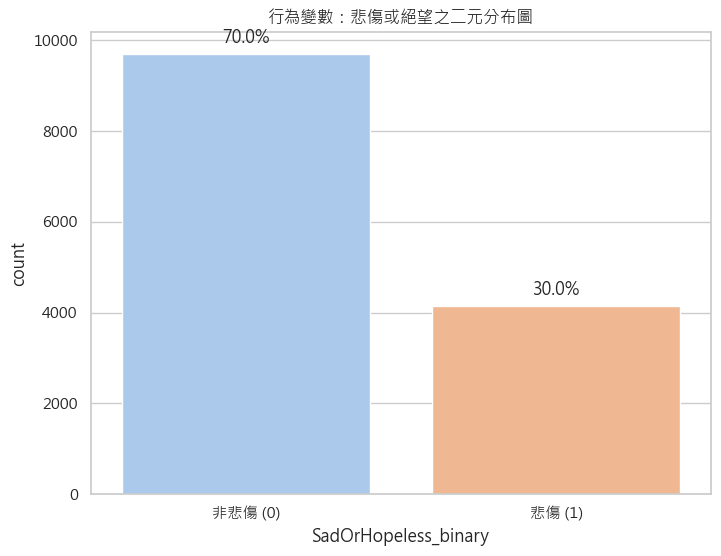

--- 行為變數觀察報告 ---
缺失值計數: 0
樣本分佈: 成功(悲傷)比例為 30.00%



In [14]:
# ==========================================
# 2. 行為變數分析 (SadOrHopeless)
# ==========================================

# (A) 原始代碼次數分配表 & 缺失值計數
# 注意：這裡假設原始資料欄位為 'SadOrHopeless'，二元欄位為 'SadOrHopeless_binary'
orig_counts = df_prop['SadOrHopeless'].value_counts(dropna=False).sort_index()
orig_table = pd.DataFrame({'次數': orig_counts, '百分比': df_prop['SadOrHopeless'].value_counts(normalize=True, dropna=False) * 100})
orig_table.to_csv(table_path / "sad_original_table.csv", encoding='utf_8_sig')

# (B) 二元重編碼後的表格 (成功與失敗計數)
binary_counts = df_prop['SadOrHopeless_binary'].value_counts().sort_index()
binary_percent = df_prop['SadOrHopeless_binary'].value_counts(normalize=True) * 100
binary_table = pd.DataFrame({'計數': binary_counts, '比例(%)': binary_percent})
binary_table.index = ['失敗 (0: 非悲傷)', '成功 (1: 悲傷)']
binary_table.to_csv(table_path / "sad_binary_summary.csv", encoding='utf_8_sig')

# (C) 繪製圖表：長條圖
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='SadOrHopeless_binary', data=df_prop, hue='SadOrHopeless_binary', palette='pastel', legend=False)
total = len(df_prop)
for p in ax.patches:
    ax.annotate(f'{100*p.get_height()/total:.1f}%', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
plt.title('行為變數：悲傷或絕望之二元分布圖')
plt.xticks([0, 1], ['非悲傷 (0)', '悲傷 (1)'])
plt.savefig(figure_path / "sad_bar_chart.png")
plt.show()

# (D) 缺失值報告 (print 到畫面上方便寫書面觀察)
sad_na = df_prop['SadOrHopeless'].isna().sum()
print(f"--- 行為變數觀察報告 ---")
print(f"缺失值計數: {sad_na}")
print(f"樣本分佈: 成功(悲傷)比例為 {binary_percent[1]:.2f}%\n")

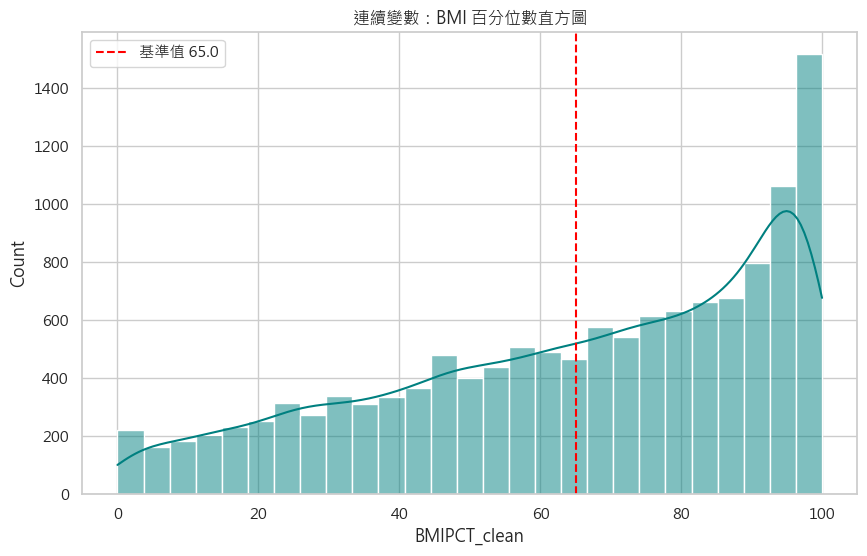

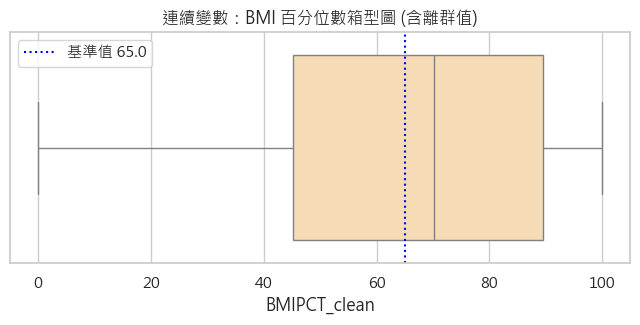

--- 連續變數觀察報告 ---
缺失值計數: 0
平均數: 64.82, 中位數: 70.14
離群值計數: 0
範圍: [0.00 ~ 99.94]

 所有要求之表格與圖表已儲存完畢。


In [16]:
# ==========================================
# 3. 連續變數分析 (BMIPCT)
# ==========================================

# (A) 樣本數、平均數、中位數、標準差、極值與四分位數
bmi_stats = df_mean['BMIPCT_clean'].describe()
# 額外補上中位數 (describe 裡的 50% 就是中位數，但我們可以另外列出)
bmi_summary = pd.DataFrame(bmi_stats)
bmi_summary.columns = ['BMI 統計描述']
bmi_summary.to_csv(table_path / "bmi_stats_summary.csv", encoding='utf_8_sig')

# (B) 離群值 (Outlier) 檢查
Q1 = bmi_stats['25%']
Q3 = bmi_stats['75%']
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df_mean[(df_mean['BMIPCT_clean'] < lower_bound) | (df_mean['BMIPCT_clean'] > upper_bound)]

# (C) 繪製圖表：直方圖
plt.figure(figsize=(10, 6))
sns.histplot(df_mean['BMIPCT_clean'], kde=True, color='teal')
plt.axvline(65.0, color='red', linestyle='--', label='基準值 65.0')
plt.title('連續變數：BMI 百分位數直方圖')
plt.legend()
plt.savefig(figure_path / "bmi_histogram.png")
plt.show()

# (D) 繪製圖表：箱型圖 (明確呈現離群值)
plt.figure(figsize=(8, 3))
sns.boxplot(x=df_mean['BMIPCT_clean'], color='navajowhite', fliersize=5)
plt.axvline(65.0, color='blue', linestyle=':', label='基準值 65.0')
plt.title('連續變數：BMI 百分位數箱型圖 (含離群值)')
plt.legend()
plt.savefig(figure_path / "bmi_boxplot.png")
plt.show()

# (E) 缺失值與觀察報告
bmi_na = df_mean['BMIPCT_clean'].isna().sum()
print(f"--- 連續變數觀察報告 ---")
print(f"缺失值計數: {bmi_na}")
print(f"平均數: {bmi_stats['mean']:.2f}, 中位數: {bmi_stats['50%']:.2f}")
print(f"離群值計數: {len(outliers)}")
print(f"範圍: [{bmi_stats['min']:.2f} ~ {bmi_stats['max']:.2f}]")

print("\n 所有要求之表格與圖表已儲存完畢。")

In [ ]:
#設定參數
count = binary_counts[1]        
nobs = len(df_prop)             
p_null = 0.30                   

#計算樣本比例
sample_p = count / nobs

#執行單一樣本比例檢定 (Z-test)
z_stat, p_value = proportions_ztest(count, nobs, value=p_null)

#建構 95% 信賴區間
ci_low, ci_high = proportion_confint(count, nobs, alpha=0.05, method='normal')

#儲存結果到表格
prop_test_res = pd.DataFrame({
    '項目': ['樣本比例', '基準值', 'Z 統計量', 'P 值', '95% CI 下界', '95% CI 上界'],
    '數值': [sample_p, p_null, z_stat, p_value, ci_low, ci_high]
})
prop_test_res.to_csv("../outputs/tables/proportion_test_results.csv", index=False, encoding='utf_8_sig')
print(prop_test_res)

          項目        數值
0       樣本比例  0.299964
1        基準值  0.300000
2      Z 統計量 -0.009273
3        P 值  0.992601
4  95% CI 下界  0.292331
5  95% CI 上界  0.307597


In [ ]:
#設定參數
data = df_mean['BMIPCT_clean']
mu_0 = 65.0                     # 基準值 mu0

#計算樣本統計量
n = len(data)
x_bar = data.mean()
s = data.std()

#執行單一樣本 t 檢定
t_stat, p_val_t = stats.ttest_1samp(data, popmean=mu_0)

#建構 95% 信賴區間 (使用 t 分布)
ci_t = stats.t.interval(confidence=0.95, df=n-1, loc=x_bar, scale=stats.sem(data))

#儲存結果到表格
mean_test_res = pd.DataFrame({
    '項目': ['樣本數', '樣本平均數', '標準差', '基準值', 't 統計量', 'P 值', 'CI 下界', 'CI 上界'],
    '數值': [n, x_bar, s, mu_0, t_stat, p_val_t, ci_t[0], ci_t[1]]
})
mean_test_res.to_csv("../outputs/tables/mean_test_results.csv", index=False, encoding='utf_8_sig')
print(mean_test_res)

      項目            數值
0    樣本數  13062.000000
1  樣本平均數     64.820683
2    標準差     27.516756
3    基準值     65.000000
4  t 統計量     -0.744781
5    P 值      0.456417
6  CI 下界     64.348750
7  CI 上界     65.292617


以下為額外EDA

比例分析:性別是否影響了悲傷比例

In [ ]:
#額外EDA
df_prop = pd.read_csv("../data/processed/yrbs_prop_analysis.csv")

# 2. 重新讀取原始資料，只抓性別和原始索引
df_raw_sex = pd.read_csv("../data/raw/YRBS_2007.csv", usecols=['WhatIsYourSex'])

# 3. 將性別合併到你現在的分析資料中
df_prop = df_prop.join(df_raw_sex, how='left')

# 4. 檢查性別的缺失值與分佈
print("性別缺失值數量：", df_prop['WhatIsYourSex'].isna().sum())
print("性別分佈：\n", df_prop['WhatIsYourSex'].value_counts(dropna=False))

# 5. 為了圖表美觀，做個簡單的標籤轉換   
df_prop['Sex_Label'] = df_prop['WhatIsYourSex'].map({1: 'Female', 2: 'Male'})

性別缺失值數量： 13
性別分佈：
 WhatIsYourSex
1.0    6927
2.0    6905
NaN      13
Name: count, dtype: int64


次數表：
 SadOrHopeless_binary   0.0   1.0
Sex_Label                       
Female                4815  2112
Male                  4865  2040

比例表：
 SadOrHopeless_binary       0.0       1.0
Sex_Label                               
Female                0.695106  0.304894
Male                  0.704562  0.295438


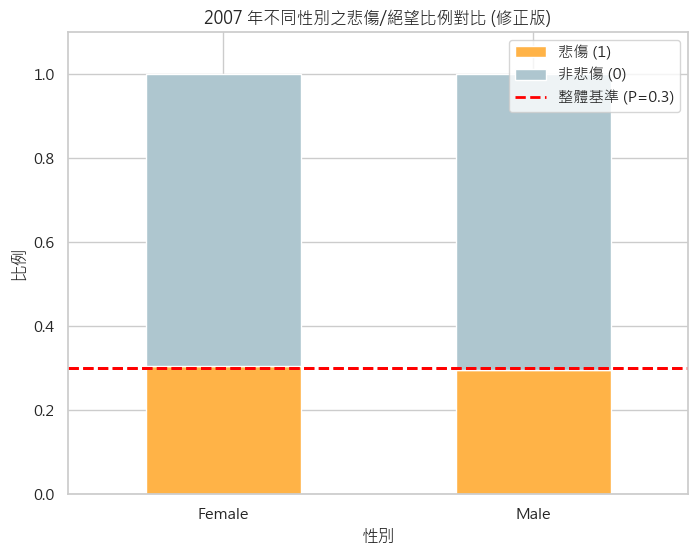

In [ ]:
df_prop['Sex_Label'] = df_prop['WhatIsYourSex'].map({1: 'Female', 2: 'Male'})

# 建立交叉表：看性別與悲傷的次數
ct_counts = pd.crosstab(df_prop['Sex_Label'], df_prop['SadOrHopeless_binary'])
print("次數表：\n", ct_counts)
ct_counts.to_csv(table_path / "sex_sad_count_table.csv")
# 建立比例表：看各性別內部的比例
ct_pct = pd.crosstab(df_prop['Sex_Label'], df_prop['SadOrHopeless_binary'], normalize='index')
print("\n比例表：\n", ct_pct)

#繪圖
ct_pct_ordered = ct_pct[[1, 0]] 

plt.figure(figsize=(8, 6))
ax = ct_pct_ordered.plot(kind='bar', stacked=True, color=['#ffb347', '#aec6cf'], ax=plt.gca())

plt.axhline(0.3, color='red', linestyle='--', linewidth=2, label='整體基準 (30%)')

plt.title('2007 年不同性別之悲傷/絕望比例對比 (修正版)')
plt.ylabel('比例')
plt.xlabel('性別')
line = plt.axhline(0.3, color='red', linestyle='--', linewidth=2)
plt.legend([ax.patches[0], ax.patches[len(ct_pct_ordered)] , line], 
           ['悲傷 (1)', '非悲傷 (0)', '整體基準 (P=0.3)'], 
           loc='upper right')
plt.xticks([0, 1], ['Female', 'Male'], rotation=0)
plt.ylim(0, 1.1)
plt.savefig(figure_path / "sex_with_sad_bar_chart.png")
plt.show()

對男女做檢定看有沒有差別

In [ ]:
current_dir = Path.cwd()
TABLES_DIR = current_dir.parent / "outputs" / "tables"

# 2. 數據
count_female_sad = 2112
count_male_sad = 2040
successes = [count_female_sad, count_male_sad]

n_female = 4815 + 2112
n_male = 4865 + 2040
nobs = [n_female, n_male]

# 3. 執行檢定 (解決 proportions_ztest 波浪線)
z_stat, p_value = proportions_ztest(count=successes, nobs=nobs)

# 4. 整理與存檔
test_results = {
    "群組": ["Female", "Male"],
    "悲傷人數": [count_female_sad, count_male_sad],
    "總人數": [n_female, n_male],
    "比例 (p)": [count_female_sad/n_female, count_male_sad/n_male],
    "Z 檢定統計量": [z_stat, ""],
    "P 值": [p_value, ""]
}

df_test_results = pd.DataFrame(test_results)
df_test_results.to_csv(TABLES_DIR / "sex_sad_proportion_z_test.csv", index=False)

print("="*30)
print("Sex Proportion Z-Test Results")
print("="*30)
print(df_test_results)

if p_value < 0.05:
    print(f"\n結論：P 值 ({p_value:.4f}) < 0.05，男女生在悲傷比例上有顯著差異。")
else:
    print(f"\n結論：P 值 ({p_value:.4f}) > 0.05，男女生在悲傷比例上沒有顯著差異。")

Sex Proportion Z-Test Results
       群組  悲傷人數   總人數    比例 (p)   Z 檢定統計量       P 值
0  Female  2112  6927  0.304894  1.213191  0.225057
1    Male  2040  6905  0.295438                    

結論：P 值 (0.2251) > 0.05，男女生在悲傷比例上沒有顯著差異。


平均數分析:感到悲傷的學生BMI分佈有沒有不同

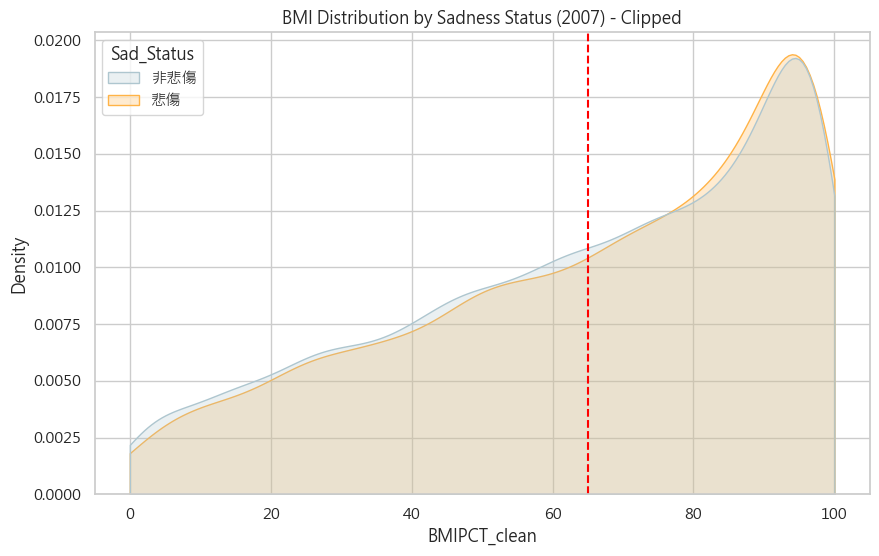

             count       mean        std           min        25%        50%  \
Sad_Status                                                                     
悲傷          3842.0  65.798882  27.357873  3.720000e-09  46.423696  71.288352   
非悲傷         9060.0  64.416979  27.568365  1.930000e-07  44.477392  69.776789   

                  75%        max  
Sad_Status                        
悲傷          90.226574  99.915189  
非悲傷         89.083347  99.939213  


In [ ]:
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

df_mean['Sad_Status'] = df_mean['SadOrHopeless_binary'].map({1: '悲傷', 0: '非悲傷'})

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_mean, x='BMIPCT_clean', hue='Sad_Status', 
            fill=True, common_norm=False, palette=['#aec6cf', '#ffb347'],
            clip=(0, 100)) 

plt.axvline(65.0, color='red', linestyle='--', label='Overall Baseline (65.0)')
plt.title('BMI Distribution by Sadness Status (2007) - Clipped')
plt.savefig(FIGURES_DIR / "bmi_kde_by_sadness.png", dpi=300)
plt.show()

bmi_sad_summary = df_mean.groupby('Sad_Status')['BMIPCT_clean'].describe()
bmi_sad_summary.to_csv(TABLES_DIR / "bmi_stats_by_sadness.csv")

print(bmi_sad_summary)

In [1]:
# 1. 準備兩組數據
bmi_sad = df_mean[df_mean['Sad_Status'] == 'Sad']['BMIPCT_clean']
bmi_not_sad = df_mean[df_mean['Sad_Status'] == 'Not Sad']['BMIPCT_clean']

# 2. 執行獨立樣本 t 檢定
t_stat, p_val_correlation = stats.ttest_ind(bmi_sad, bmi_not_sad, nan_policy='omit')

# 3. 整理成表格
correlation_test_results = pd.DataFrame({
    "分析對象": ["悲傷組 vs 非悲傷組 (BMI)"],
    "悲傷組平均": [bmi_sad.mean()],
    "非悲傷組平均": [bmi_not_sad.mean()],
    "平均差異": [bmi_sad.mean() - bmi_not_sad.mean()],
    "t 統計量": [t_stat],
    "P 值": [p_val_correlation]
})

# 4. 存檔到妳現有的 tables 資料夾
# 假設妳已經定義好 TABLES_DIR
correlation_test_results.to_csv(TABLES_DIR / "bmi_sadness_correlation_test.csv", index=False)

print("="*30)
print("心理與生理指標關聯性檢定")
print("="*30)
print(correlation_test_results)

# 5. 自動判斷
if p_val_correlation < 0.05:
    print(f"\n結論：P 值 ({p_val_correlation:.4f}) < 0.05，兩組 BMI 有顯著差異！心理與生理指標存在統計上的關聯。")
else:
    print(f"\n結論：P 值 ({p_val_correlation:.4f}) > 0.05，兩組 BMI 沒有顯著差異。")

NameError: name 'df_mean' is not defined